# Fine-tuning DistilBERT do przewidywania ocen filmowych

## Cel projektu
Notebook demonstruje fine-tuning modelu **DistilBERT** na danych z Letterboxd w celu przewidywania ocen filmowych na podstawie opisu filmu (`overview`). Jest to zadanie **regresji**: model ma nauczyć się mapowania tekstu na wartość liczbową (ocena 0–10).

## Źródło danych
Dataset publiczny z Kaggle: **"Letterboxd Movie Ratings Data"** (samlearner). Zawiera oceny użytkowników platformy Letterboxd oraz metadane filmów z TMDB.

## 1. Wczytywanie danych

In [1]:
import kagglehub
import pandas as pd
from pathlib import Path

path = Path(kagglehub.dataset_download("samlearner/letterboxd-movie-ratings-data"))

movie_data = pd.read_csv(path / "movie_data.csv", on_bad_lines="skip", engine="python")
ratings_data = pd.read_csv(
    path / "ratings_export.csv", on_bad_lines="skip", engine="python"
)

display(movie_data.head())

c:\Users\Maciek\ProjektPythonVistula2026\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,_id,genres,image_url,imdb_id,imdb_link,movie_id,movie_title,original_language,overview,popularity,production_countries,release_date,runtime,spoken_languages,tmdb_id,tmdb_link,vote_average,vote_count,year_released
0,5fc85f606758f69634496fd3,"[""Music"",""Animation""]",film-poster/4/6/4/4/4/0/464440-football-freaks...,NaN,NaN,football-freaks,Football Freaks,en,"Football crazy, football mad. Don’t watch this...",0.600,"[""United Kingdom""]",1971-12-05,0.0,[],535272.0,https://www.themoviedb.org/movie/535272/,0.0,0.0,1971.0
1,5fc85ff26758f696344ace0c,[],film-poster/2/4/5/5/0/0/245500-aftermath-0-230...,tt0586129,http://www.imdb.com/title/tt0586129/maindetails,aftermath-1960,Aftermath,en,Aftermath was the pilot for an unsold TV serie...,0.600,[],1960-04-17,22.0,[],318331.0,https://www.themoviedb.org/movie/318331/,8.0,1.0,1960.0
2,5fc85f606758f69634496fcd,"[""Drama""]",film-poster/9/3/3/1/8/93318-where-chimneys-are...,tt0045731,http://www.imdb.com/title/tt0045731/maindetails,where-chimneys-are-seen,Where Chimneys Are Seen,ja,Gosho’s most celebrated film both in Japan and...,1.568,"[""Japan""]",1953-03-05,108.0,"[""日本語""]",117779.0,https://www.themoviedb.org/movie/117779/,6.6,10.0,1953.0
3,5fc85f606758f69634496fd1,"[""Drama""]",NaN,tt0187327,http://www.imdb.com/title/tt0187327/maindetails,the-musicians-daughter,The Musician's Daughter,en,Carl Wagner's good wife was dying. His heart b...,0.600,"[""United States of America""]",1911-12-12,15.0,[],560377.0,https://www.themoviedb.org/movie/560377/,0.0,0.0,1911.0
4,5fc85f606758f69634496fd4,"[""Documentary""]",film-poster/4/5/4/6/0/3/454603-50-years-of-fab...,tt4769914,http://www.imdb.com/title/tt4769914/maindetails,50-years-of-fabulous,50 Years of Fabulous,en,50 Years of Fabulous recounts the rich history...,0.600,[],2018-05-17,75.0,[],525187.0,https://www.themoviedb.org/movie/525187/,0.0,0.0,2018.0


## 2. Przygotowanie danych

Filtrujemy oceny wybranego użytkownika i łączymy je z metadanymi filmów. Do treningu używamy tylko filmów, które mają opis (`overview`) - bez niego model nie ma wejścia.

Wybrany użytkownik: **shiftless** - aktywny recenzent z ponad 3700 ocenami filmów z opisami, co zapewnia wystarczającą ilość danych do treningu.

In [3]:
# Przygotowanie danych (czyszczenie i filtrowanie)
chosen_user = "shiftless"

user_ratings = ratings_data[ratings_data["user_id"] == chosen_user]
movie_data = movie_data.drop_duplicates(subset=["movie_id"])
merged_data = pd.merge(
    user_ratings, movie_data, left_on="movie_id", right_on="movie_id", how="inner"
)
final_dataset = merged_data[["overview", "rating_val"]]
final_dataset = final_dataset.dropna(subset=["overview"])
final_dataset["rating_val"] = final_dataset["rating_val"].astype(float)

print(f"Liczba filmów gotowych do treningu: {len(final_dataset)}")
display(final_dataset.head())

Liczba filmów gotowych do treningu: 3721


,overview,rating_val
0,Sinbad and his crew intercept a homunculus car...,8.0
1,"Will Lockhart arrives in Coronado, an isolated...",8.0
2,A hard-drinking reporter tries to help the emb...,6.0
3,"The French Revolution, 1794. The Marquis de La...",7.0
4,Genial shopkeeper Philip has to endure the con...,7.0


Rozkład ocen użytkownika shiftless:
rating_val
1.0        5
2.0       17
3.0       50
4.0      157
5.0      572
6.0     1178
7.0     1166
8.0      441
9.0      102
10.0      33
Name: count, dtype: int64


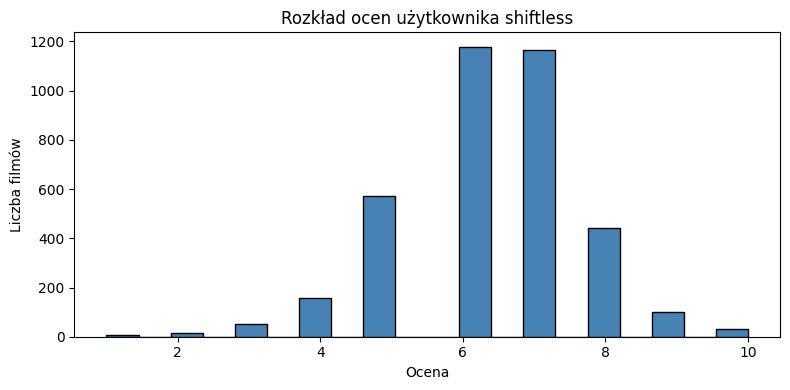


Średnia ocena: 6.36
Odchylenie standardowe: 1.26


In [4]:
import matplotlib.pyplot as plt

print(f"Rozkład ocen użytkownika {chosen_user}:")
print(final_dataset["rating_val"].value_counts().sort_index())

plt.figure(figsize=(8, 4))
plt.hist(final_dataset["rating_val"], bins=20, color="steelblue", edgecolor="black")
plt.title(f"Rozkład ocen użytkownika {chosen_user}")
plt.xlabel("Ocena")
plt.ylabel("Liczba filmów")
plt.tight_layout()
plt.show()

print(f"\nŚrednia ocena: {final_dataset['rating_val'].mean():.2f}")
print(f"Odchylenie standardowe: {final_dataset['rating_val'].std():.2f}")

## 3. Tokenizacja i przygotowanie datasetu

Tokenizacja przekształca opisy filmów na tensory liczb (token IDs) zrozumiałe dla DistilBERT. Parametr `truncation=True` obcina sekwencje dłuższe niż 512 tokenów (limit modelu), `padding="max_length"` dopełnia wszystkie sekwencje do jednakowej długości - jest to prostsze, choć pamięciowo mniej efektywne niż dynamiczne dopełnianie.

In [5]:
import sys
import numpy as np

# On Linux, pytorch-triton-rocm ships an incomplete triton build that crashes
# torch._dynamo. Block it so torch skips all JIT/triton paths.
# On Windows triton is not present anyway, so this block is a no-op there.
if sys.platform == "linux":
    sys.modules["triton"] = None
    import torch
    from torch.utils._triton import has_triton_package
    has_triton_package.cache_clear()
else:
    import torch

from datasets import Dataset
from transformers import AutoTokenizer

In [6]:
# Przygotowanie danych (tokenizacja)

# konwersja danych na zrozumiałe dla trenera
final_dataset = final_dataset.rename(columns={"rating_val": "label"})
hf_dataset = Dataset.from_pandas(final_dataset)
# podział danych na test i train
hf_dataset = hf_dataset.train_test_split(test_size=0.2, seed=42)

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")


def tokenize_function(examples):
    return tokenizer(
        examples["overview"], padding="max_length", truncation=True, max_length=512
    )


tokenized_datasets = hf_dataset.map(tokenize_function, batched=True)

print(tokenized_datasets)

Map: 100%|██████████| 745/745 [00:00<00:00, 7672.69 examples/s]

DatasetDict({
    train: Dataset({
        features: ['overview', 'label', '__index_level_0__', 'input_ids', 'attention_mask'],
        num_rows: 2976
    })
    test: Dataset({
        features: ['overview', 'label', '__index_level_0__', 'input_ids', 'attention_mask'],
        num_rows: 745
    })
})


In [7]:
import evaluate
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

## 4. Fine-tuning modelu DistilBERT

Ładujemy pretrenowany model DistilBERT z nową głowicą regresji (`num_labels=1`). Komunikaty `MISSING` i `UNEXPECTED` w logu ładowania są **oczekiwane**: stare wagi głowicy językowej (`vocab_projector`, `vocab_transform`, itd.) są odrzucane, a nowa głowica klasyfikacyjna (`classifier`, `pre_classifier`) jest inicjalizowana losowo - to właśnie ona będzie trenowana.

Jako metrykę ewaluacyjną używamy **MAE (Mean Absolute Error)** - średni błąd bezwzględny między przewidzianą a rzeczywistą oceną w skali 0–10.

In [10]:
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=1
)

metric = evaluate.load("mae")


def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.squeeze(predictions)
    return metric.compute(predictions=predictions, references=labels)


training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=2,
    eval_strategy="epoch",
    learning_rate=2e-5,
    save_strategy="epoch",
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    fp16=torch.cuda.is_available(),
)


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    compute_metrics=compute_metrics,
)


trainer.train()

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Mae
1,4.046100,1.468539,0.939781
2,1.614200,1.391862,0.901159


TrainOutput(global_step=1488, training_loss=2.3684879426033265, metrics={'train_runtime': 195.2434, 'train_samples_per_second': 30.485, 'train_steps_per_second': 7.621, 'total_flos': 788431895986176.0, 'train_loss': 2.3684879426033265, 'epoch': 2.0})

## 5. Wyniki i ewaluacja

Po zakończeniu treningu obliczamy finalne metryki na zbiorze testowym i sprawdzamy działanie modelu na kilku przykładowych opisach.

In [11]:
results = trainer.evaluate()
mae = results["eval_mae"]
print(f"Finalne MAE na zbiorze testowym: {mae:.4f}")
print(f"Model myli się średnio o {mae:.2f} punktu na skali 0–10.")

Finalne MAE na zbiorze testowym: 0.9012
Model myli się średnio o 0.90 punktu na skali 0–10.


In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.eval()

sample_texts = [
    "A group of astronauts embarks on a dangerous mission to save humanity from extinction.",
    "A romantic comedy about two strangers who fall in love during a weekend trip to Paris.",
    "A dark psychological thriller about a detective hunting a serial killer.",
]

print("Przykładowe predykcje modelu:\n")
for text in sample_texts:
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512, padding=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        output = model(**inputs)
    pred = output.logits.squeeze().item()
    print(f"Tekst:               {text[:70]}...")
    print(f"Przewidziana ocena:  {pred:.2f}\n")

Przykładowe predykcje modelu:

Tekst:               A group of astronauts embarks on a dangerous mission to save humanity ...
Przewidziana ocena:  5.31

Tekst:               A romantic comedy about two strangers who fall in love during a weeken...
Przewidziana ocena:  6.86

Tekst:               A dark psychological thriller about a detective hunting a serial kille...
Przewidziana ocena:  6.46



In [13]:
trainer.save_model("./saved_model")
tokenizer.save_pretrained("./saved_model")
print("Model i tokenizer zapisane w katalogu: ./saved_model")

Model i tokenizer zapisane w katalogu: ./saved_model


## Wnioski

1. **Wyniki modelu:** MAE ≈ 0.89 na zbiorze testowym po 2 epokach oznacza, że model myli się średnio o niecały 1 punkt na skali 0–10 - wynik obiecujący, biorąc pod uwagę, że model opiera się wyłącznie na opisach filmów.

2. **Ograniczenia:** Model jest dopasowany do gustu jednego użytkownika (`shiftless`) i nie generalizuje na innych. Opis fabuły (`overview`) nie zawsze odzwierciedla subiektywne preferencje - ten sam film może być oceniony na 3 lub 9 przez różnych widzów.

3. **Możliwe ulepszenia:**
   - Więcej epok treningu (3-5) z wczesnym zatrzymaniem (`load_best_model_at_end=True`)
   - Dodanie cech kontekstowych (gatunki, rok produkcji)
   - Przetestowanie większych modeli (BERT-base, RoBERTa)
   - Normalizacja etykiet do zakresu [0, 1] dla stabilniejszego treningu